# Crop Disease Detection using Vision Transformer (ViT)

This notebook builds, trains and evaluates a Vision Transformer model for crop disease detection using TensorFlow and Keras.

Dataset structure:
- train/
  - potato_early_blight/
  - potato_late_blight/
  - potato_healthy/
- validation/
  - same structure as train
- test/
  - same structure as train

In [17]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.18.0
Keras version: 3.8.0


## 1. Data Loading and Preprocessing

In [26]:
# Define paths to data directories
# Update these paths according to your data location
train_dir = '/kaggle/input/potato/POTATO DATASET/train'
val_dir = '/kaggle/input/potato/POTATO DATASET/val'
test_dir = '/kaggle/input/potato/POTATO DATASET/test'

# Image parameters
IMG_SIZE = 224
BATCH_SIZE = 128

# Check if the directories exist
for directory in [train_dir, val_dir, test_dir]:
    if not os.path.exists(directory):
        raise ValueError(f"Directory not found: {directory}")

In [27]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Create data augmentation for training images
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,              # Normalize pixel values
    rotation_range=20,           # Random rotation
    width_shift_range=0.2,       # Random horizontal shift
    height_shift_range=0.2,      # Rrandom vertical shift
    shear_range=0.2,             # Shear transformations
    zoom_range=0.2,              # Random zoom
    horizontal_flip=True,        # Random horizontal flip
    brightness_range=(0.8, 1.2), # Brightness adjustment
    fill_mode='nearest'          # Fill strategy for created pixels
)

# Validation and test data should only be normalized, not augmented
val_datagen = keras.preprocessing.image.ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = keras.preprocessing.image.ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators for train, validation, and test sets
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Don't shuffle test data to maintain order for evaluation
)

# Get class names and number of classes
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 2100 images belonging to 3 classes.
Found 450 images belonging to 3 classes.
Found 450 images belonging to 3 classes.
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 3
Training samples: 2100
Validation samples: 450
Test samples: 450


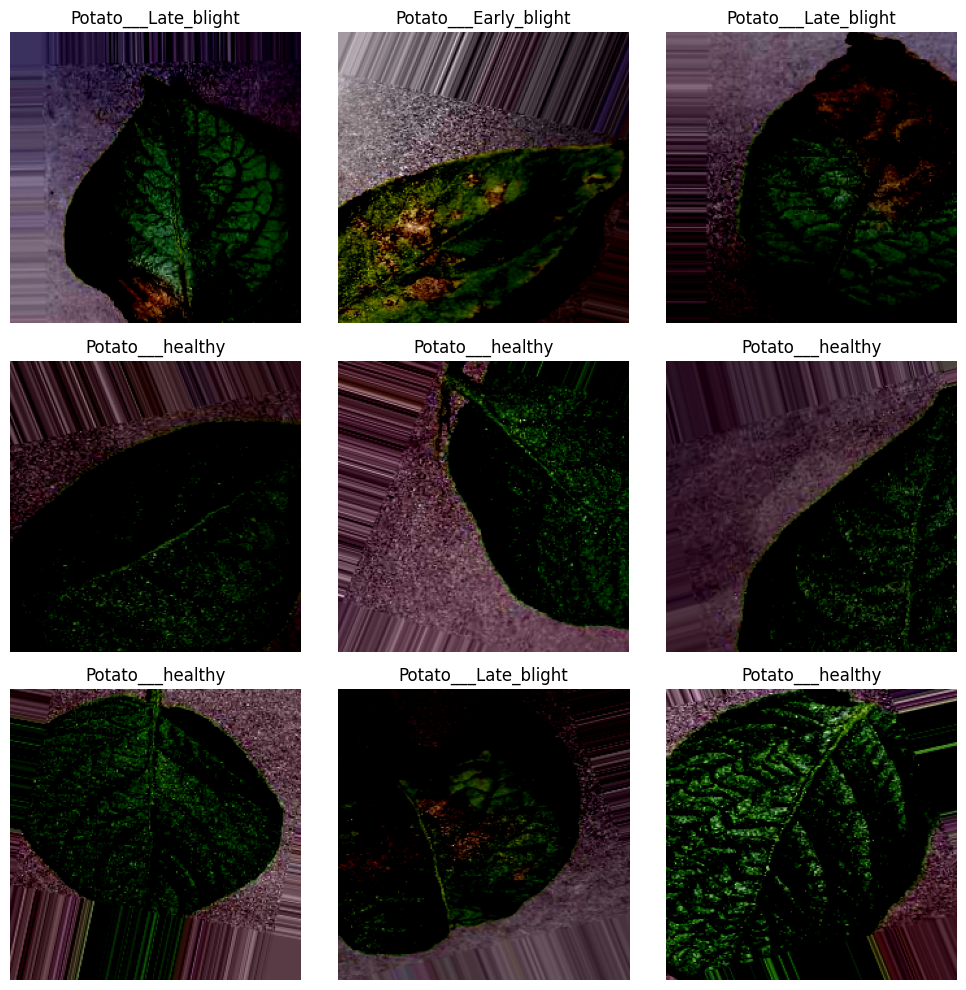

In [28]:
# Visualize some training samples with augmentation
def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(image_batch))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i])
        plt.title(class_names[np.argmax(label_batch[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Get a batch of training images and labels
image_batch, label_batch = next(train_generator)
show_batch(image_batch, label_batch)

## 2. Model Creation

In [29]:
from keras.applications import MobileNetV2
from tensorflow.keras import regularizers

def create_model():
    """Create a Vision Transformer model using EfficientNetB0 as base"""
    # Load the EfficientNetB0 model with pre-trained weights
    base_model = MobileNetV2(
        include_top=False,           # Exclude the classification head
        weights='imagenet',          # Pre-trained on ImageNet
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # Freeze the base model layers initially
    base_model.trainable = False
    # Add custom classification head
    inputs = keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)

    # Global average pooling to reduce dimensions
    x = keras.layers.GlobalAveragePooling2D()(x)

    # Add dropout and dense layers for classification
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)  # Dropout to prevent overfitting
    x = keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = keras.Model(inputs, outputs)

    return model

# Create the model
model = create_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,811 (9.89 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 3. Training

In [30]:
# Set up simplified training parameters
EPOCHS_PHASE1 = 10   # Reduced from 10 for quicker iterations
EPOCHS_PHASE2 = 25  # Reduced from 20 for quicker iterations

# Simplify the optimizer - use standard Adam with fixed learning rate
optimizer = keras.optimizers.Adam(learning_rate=1e-3)  # Fixed learning rate

# Compile the model with simplified settings
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Simplified callbacks - just keep the essential ones
checkpoint_path = "potato_MobileNetV2_bestmodel_.h5"
callbacks = [
    # Save the best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Early stopping to prevent overfitting
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,                # Reduced from 10
        restore_best_weights=True
    )
]


In [31]:
# Phase 1: Train only the top layers (feature extraction)
print("Phase 1: Training only the top layers")
# Ensure base model layers are frozen (not trainable)
base_model = model.layers[1]
base_model.trainable = False

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks
)


Phase 1: Training only the top layers
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7231 - loss: 0.7574
Epoch 1: val_accuracy improved from -inf to 0.83111, saving model to potato_MobileNetV2_bestmodel_.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7308 - loss: 0.7377 - val_accuracy: 0.8311 - val_loss: 0.4219
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9582 - loss: 0.1678
Epoch 2: val_accuracy improved from 0.83111 to 0.89778, saving model to potato_MobileNetV2_bestmodel_.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9582 - loss: 0.1673 - val_accuracy: 0.8978 - val_loss: 0.2602
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9703 - loss: 0.1196
Epoch 3: val_accuracy did not improve from 0.89778
17/17 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9703 - loss: 0.1198 - val_accuracy: 0.8933 - val_loss: 0.2638
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9748 - loss: 0.1201
Epoch 4: val_accuracy impro

In [32]:

base_model = model.layers[1]

len(base_model.layers)

154

In [33]:
print("Phase 2: Fine-tuning the model")

# Access the base model and make some layers trainable
base_model = model.layers[1]
base_model.trainable = True

# Freeze earlier layers, unfreeze later layers
# For VGG16, there are 19 layers - freeze first 14, train last 5
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= 109)  # Only train the last 5 layers

# Use a lower learning rate for fine-tuning
optimizer_finetune = keras.optimizers.Adam(learning_rate=1e-5)  # 10x smaller

# Recompile the model with the new learning rate
model.compile(
    optimizer=optimizer_finetune,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary of trainable vs non-trainable layers
print(f"Total layers in the model: {len(model.layers)}")
print(f"Trainable weights: {len(model.trainable_weights)}")
print(f"Non-trainable weights: {len(model.non_trainable_weights)}")

# Continue training
history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE2,
    initial_epoch=EPOCHS_PHASE1,  # Continue from where we left off
    callbacks=callbacks
)


Phase 2: Fine-tuning the model
Total layers in the model: 8
Trainable weights: 51
Non-trainable weights: 217
Epoch 11/25


E0000 00:00:1760083004.406969     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760083004.613408     121 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 9/17 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9022 - loss: 0.3476

E0000 00:00:1760083026.715807     122 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760083026.915647     122 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9070 - loss: 0.3335
Epoch 11: val_accuracy did not improve from 0.98000
17/17 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9075 - loss: 0.3327 - val_accuracy: 0.9733 - val_loss: 0.0963
Epoch 12/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9404 - loss: 0.2254
Epoch 12: val_accuracy improved from 0.98000 to 0.98667, saving model to potato_MobileNetV2_bestmodel_.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9404 - loss: 0.2246 - val_accuracy: 0.9867 - val_loss: 0.0870
Epoch 13/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9486 - loss: 0.1795
Epoch 13: val_accuracy did not improve from 0.98667
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9488 - loss: 0.1794 - val_accuracy: 0.9867 - val_loss: 0.0836
Epoch 14/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9572 - loss: 0.1589
Epoch 14: val_accuracy did not improve from 0.98667
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9576 - loss: 0.1

In [35]:
# Combine the histories from both training phases
history = {}
for key in history_phase1.history.keys():
    history[key] = history_phase1.history[key] + history_phase2.history[key]

# Load the best model weights from checkpoint
model.load_weights(checkpoint_path)
eval_result = model.evaluate(validation_generator)
print(f"Final validation accuracy: {eval_result[1]:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.9914 - loss: 0.0669
Final validation accuracy: 0.9889


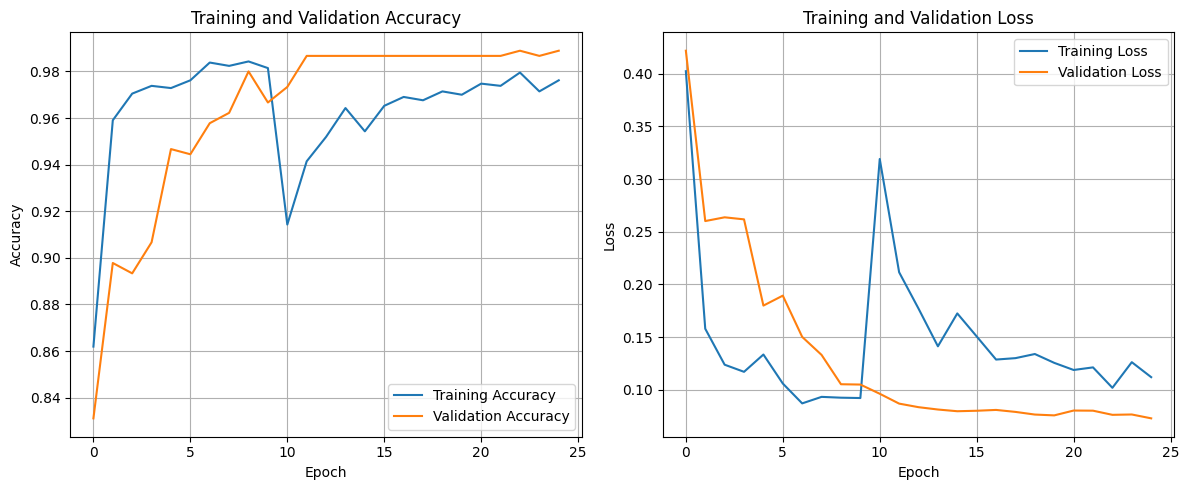

In [36]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Model Evaluation

In [37]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.9941 - loss: 0.0567
Test Loss: 0.0560
Test Accuracy: 0.9956


In [38]:
# Get predictions for the test set
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

# Make sure predictions and true labels have the same length
print(f"Number of test samples: {len(y_true)}")
print(f"Number of predictions: {len(y_pred)}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step  
Number of test samples: 450
Number of predictions: 450


In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report

# Calculate additional metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Generate detailed classification report
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Create a DataFrame for better visualization
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

Precision: 0.9956
Recall: 0.9956
F1 Score: 0.9956

Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.99      0.99      0.99       150
 Potato___Late_blight       0.99      0.99      0.99       150
     Potato___healthy       1.00      1.00      1.00       150

             accuracy                           1.00       450
            macro avg       1.00      1.00      1.00       450
         weighted avg       1.00      1.00      1.00       450



,precision,recall,f1-score,support
Potato___Early_blight,0.993333,0.993333,0.993333,150.000000
Potato___Late_blight,0.993333,0.993333,0.993333,150.000000
Potato___healthy,1.000000,1.000000,1.000000,150.000000
accuracy,0.995556,0.995556,0.995556,0.995556
macro avg,0.995556,0.995556,0.995556,450.000000
weighted avg,0.995556,0.995556,0.995556,450.000000


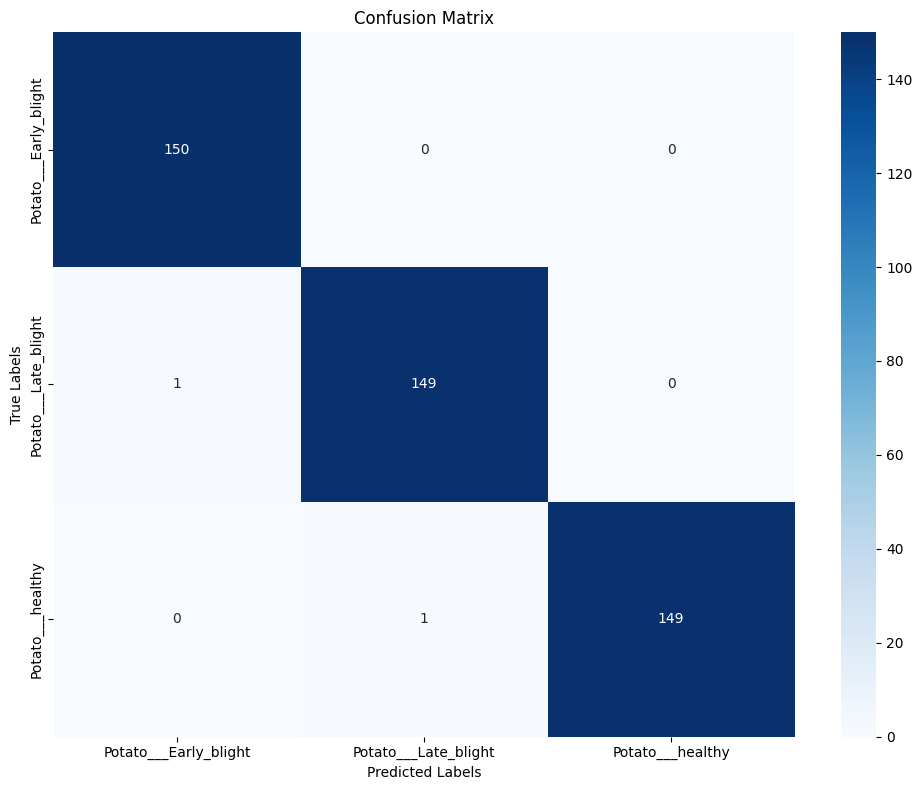

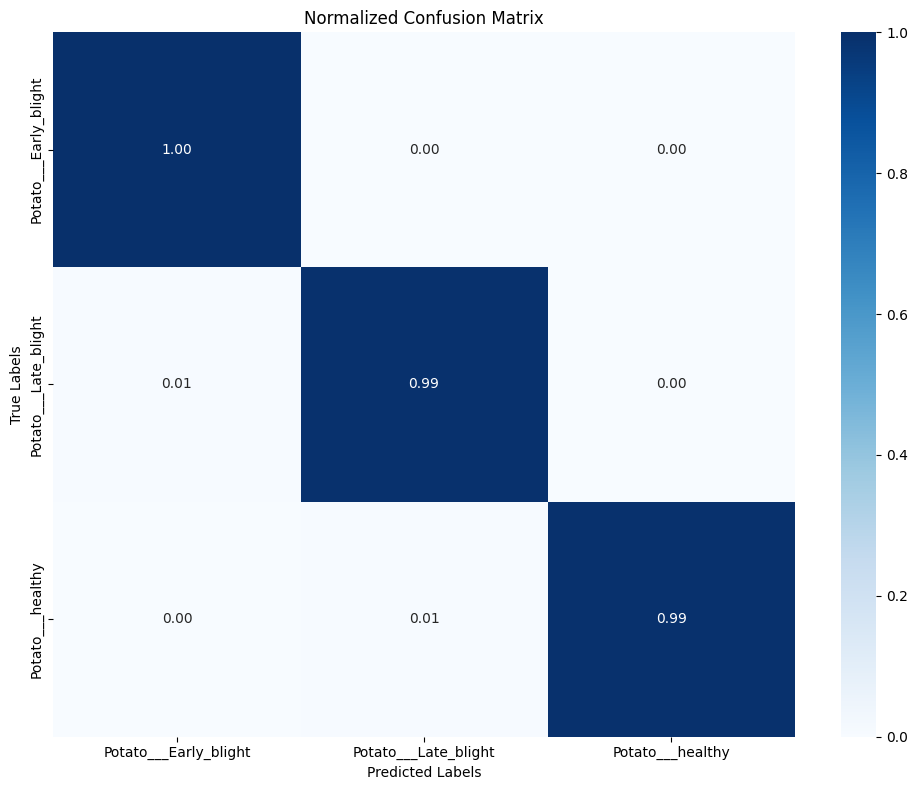

In [16]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

## 5. Prediction on New Images

In [ ]:
def predict_disease(image_path_or_url, is_url=False):
    """
    Predict crop disease from an image file or URL

    Args:
        image_path_or_url (str): Path to local image or URL
        is_url (bool): Flag to indicate if input is a URL

    Returns:
        tuple: (predicted_class_name, confidence)
    """
    try:
        # Load the image
        if is_url:
            response = requests.get(image_path_or_url)
            img = Image.open(BytesIO(response.content))
        else:
            img = Image.open(image_path_or_url)

        # Convert to RGB if needed (handle PNG transparency)
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # Preprocess the image
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = keras.preprocessing.image.img_to_array(img_resized)
        img_array = img_array / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make prediction
        predictions = model.predict(img_array, verbose=0)

        # Get the predicted class and confidence
        predicted_class_idx = np.argmax(predictions[0])
        confidence = float(predictions[0][predicted_class_idx])
        predicted_class_name = class_names[predicted_class_idx]

        # Display the image with prediction
        plt.figure(figsize=(8, 6))
        plt.imshow(img_resized)
        plt.title(f"Prediction: {predicted_class_name}\nConfidence: {confidence:.2f}", fontsize=14)
        plt.axis('off')
        plt.show()

        # Print all class probabilities
        print("Class probabilities:")
        for i, (cls, prob) in enumerate(zip(class_names, predictions[0])):
            print(f"{cls}: {prob:.4f}")

        return predicted_class_name, confidence

    except Exception as e:
        print(f"Error occurred: {str(e)}")
        return None, None

In [ ]:
# Example 1: Predict from a local file
# Update with path to your test image
# predict_disease("path/to/test_image.jpg")

# Example 2: Predict from a URL
# predict_disease("https://example.com/crop_image.jpg", is_url=True)

In [40]:
# Save the trained model for future use
model.save('potato_MobileNetv2_save.h5')
print("Model saved successfully!")

Model saved successfully!


## Conclusion

In this notebook, we built a Vision Transformer (ViT) model using EfficientNetB0 as the base architecture for crop disease detection. We:

1. Loaded and preprocessed the dataset with data augmentation
2. Created the model architecture
3. Trained the model using a two-phase approach (feature extraction and fine-tuning)
4. Evaluated the model performance using various metrics
5. Created a function to make predictions on new images

The model can be further improved by:
- Trying different architectures
- Implementing more advanced augmentation techniques
- Experimenting with different learning rates and optimizers
- Using techniques like gradient accumulation for larger batch sizes
- Applying more advanced regularization techniques